In [59]:
from dotenv import load_dotenv
load_dotenv()

True

In [60]:
from pydantic import BaseModel, Field
from typing import List, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

Agents - Coding, GoogleSearch and Weather

In [61]:
class FlowState(BaseModel):
    query : str = Field(description="Type the query here...")
    category : Literal ['coding','search','weather'] = Field(default='search')
    answer : str = Field(default='')
    

tools

In [62]:
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

In [63]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [64]:
search = GoogleSerperAPIWrapper()

In [65]:
@tool
def google_search(query: str) -> str:
    """Search Google for information."""
    return search.run(query)

google_agent = create_agent(model =llm, tools=[google_search], system_prompt="you are a google agent and you find answers for the query asked by user using google search tool")

In [74]:
weather_agent = create_agent(model =llm, tools = [google_search], system_prompt="""You are a weather agent.
    Provide current weather and weather forecasts for the city
    requested by the user. Use Google Search to obtain up-to-date
    weather information.
    """)


Nodes creation

In [67]:
class questionCategory(BaseModel):
    category : Literal['coding','search','weather'] = Field(default="search")

In [78]:
def check_ques_category(state: FlowState) -> Literal['coding', 'search', 'weather']:
    
    res = llm.invoke(
        f"""
        Classify the following question into exactly ONE category:

        coding
        search
        weather

        Question: {state.query}

        Return ONLY the category name.
        """
    )

    category = res.content.strip().lower()

    if category not in ["coding", "search", "weather"]:
        category = "search"

    state.category = category

    return category

In [79]:
def coding_route(state: FlowState)->FlowState:
    print("coding node...")
    res = llm.invoke(f"you are a coding expert {state.query}")
    state.answer = res.content
    return state

def search_route ( state: FlowState)-> FlowState:
    print("search node..")
    res = google_agent.invoke({"messages":[{"role":"user","content":state.query}]})
    state.answer = res["messages"][-1].content
    return state

def weather_route ( state: FlowState)-> FlowState:
    print("weather node..")
    res = weather_agent.invoke({"messages":[{"role":"user","content":state.query}]})
    state.answer = res["messages"][-1].content
    return state

In [80]:
graph = StateGraph(FlowState)

graph.add_node("coding", coding_route)
graph.add_node("search", search_route)
graph.add_node("weather",weather_route)
graph.add_node("check_question_category", check_ques_category)

graph.add_conditional_edges(START,check_ques_category)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("search", END)


graph= graph.compile()

In [81]:
res = graph.invoke({"query":"what is the climate in bhayander "})
res

weather node..


{'query': 'what is the climate in bhayander ',
 'category': 'search',
 'answer': '**Bhayander (Mira‑Bhayandar), Maharashtra – Weather Overview (as of the latest update)**  \n\n| Item | Current | Details |\n|------|---------|---------|\n| **Temperature** | **≈\u202f28\u202f°C** (≈\u202f82\u202f°F) | Feels like 28\u202f°C, pleasant. |\n| **Weather condition** | **Patchy rain / scattered showers** | Light rain is falling now, with occasional sunny breaks. |\n| **Humidity** | **≈\u202f79\u202f%** | High – expect the air to feel a bit muggy. |\n| **Wind** | **≈\u202f18\u202fkm/h (≈\u202f11\u202fmph) from the SW** | Gusts up to 20\u202fkm/h. |\n| **Pressure** | **≈\u202f1012\u202fhPa** | Typical for this time of year. |\n| **Visibility** | **≈\u202f8–10\u202fkm** | No major fog or haze. |\n| **UV Index** | **≈\u202f5 (moderate)** | Sun protection recommended if you go outside. |\n\n---\n\n### Short‑Term Forecast (Today\u202f+\u202fTomorrow)\n\n| Time (local) | Temp (°C) | Condition | Chance 

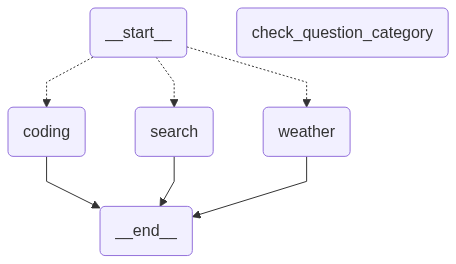

In [72]:
graph